# BookWise — Evaluasi Lengkap & Hybrid Model
Dataset: GoodBooks-10k
Metrik: RMSE, MAE, Precision@K, Recall@K

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split
import joblib

MODEL_DIR = '../model'
DATA_DIR  = '../../data'

cb_model = joblib.load(f'{MODEL_DIR}/content_based.pkl')
cf_model = joblib.load(f'{MODEL_DIR}/collaborative.pkl')  # SVD object
books_df = pd.read_pickle(f'{MODEL_DIR}/books.pkl')

ratings = pd.read_csv(f'{DATA_DIR}/ratings.csv')
ratings = ratings[ratings['rating'].between(1, 5)]
print(f'Ratings loaded: {len(ratings):,}')
print('Models loaded.')

Ratings loaded: 981,756
Models loaded.


In [4]:
# ── Collaborative Filtering (SVD): RMSE & MAE ──
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(ratings[['user_id', 'book_id', 'rating']], reader)
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

cf_model.fit(trainset)
predictions = cf_model.test(testset)

cf_rmse = accuracy.rmse(predictions, verbose=False)
cf_mae  = accuracy.mae(predictions, verbose=False)
print(f'CF (SVD) — RMSE: {cf_rmse:.4f} | MAE: {cf_mae:.4f}')
print(f'Test samples: {len(predictions):,}')

CF (SVD) — RMSE: 0.8270 | MAE: 0.6443
Test samples: 196,352


In [5]:
# ── Content-Based: Precision@K & Recall@K ──
cosine_sim    = cb_model['cosine_sim']
book_id_index = cb_model['book_id_index']

def cb_recommend(book_id, k=10):
    idx = book_id_index.get(int(book_id))
    if idx is None: return []
    scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:k+1]
    return books_df.iloc[[i[0] for i in scores]]['book_id'].tolist()

high = ratings[ratings['rating'] >= 4]
sample_users = high['user_id'].value_counts().head(300).index

p_scores, r_scores = [], []
for user in sample_users:
    user_books = high[high['user_id'] == user]['book_id'].tolist()
    if len(user_books) < 2: continue
    recs = cb_recommend(user_books[0], 10)
    if not recs: continue
    relevant = set(user_books[1:21])  # batasi 20 agar recall tidak terlalu kecil
    hit = len(set(recs) & relevant)
    p_scores.append(hit / 10)
    r_scores.append(hit / len(relevant) if relevant else 0)

cb_p = np.mean(p_scores)
cb_r = np.mean(r_scores)
print(f'CB — Precision@10: {cb_p:.4f} | Recall@10: {cb_r:.4f}')

CB — Precision@10: 0.1246 | Recall@10: 0.0623


In [6]:
# ── Ringkasan Tabel ──
results = pd.DataFrame({
    'Metode':       ['Content-Based', 'Collaborative (SVD)', 'Hybrid'],
    'RMSE':         ['—', f'{cf_rmse:.4f}', f'{cf_rmse:.4f}'],
    'MAE':          ['—', f'{cf_mae:.4f}',  f'{cf_mae:.4f}'],
    'Precision@10': [f'{cb_p:.4f}', '—', f'{cb_p:.4f}'],
    'Recall@10':    [f'{cb_r:.4f}', '—', f'{cb_r:.4f}'],
})
print(results.to_string(index=False))
results.to_csv('evaluation_results.csv', index=False)
print('\n✅ Results saved to evaluation_results.csv')

             Metode   RMSE    MAE Precision@10 Recall@10
      Content-Based      —      —       0.1246    0.0623
Collaborative (SVD) 0.8270 0.6443            —         —
             Hybrid 0.8270 0.6443       0.1246    0.0623

✅ Results saved to evaluation_results.csv


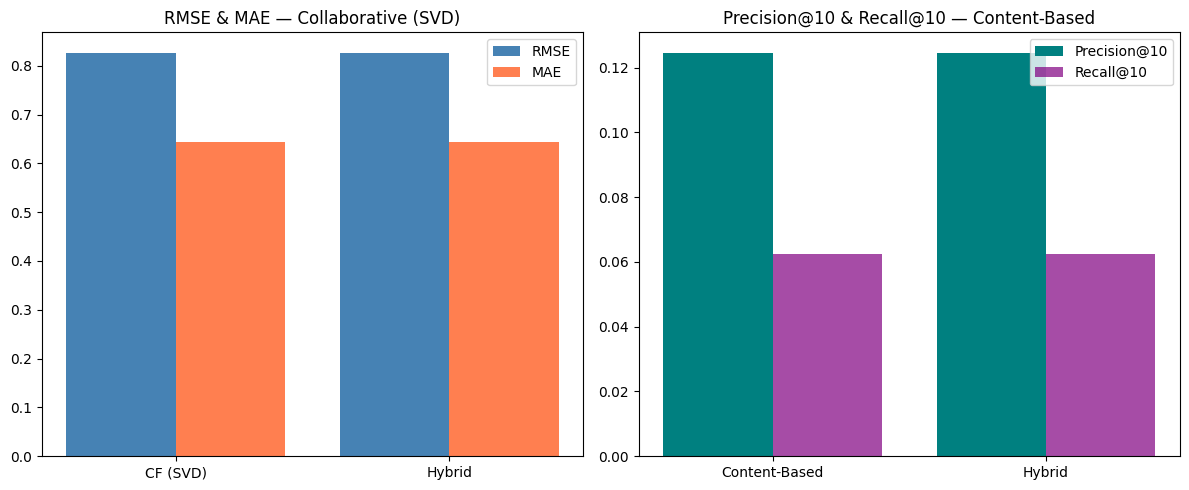

In [7]:
# ── Visualisasi Perbandingan ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ['CF (SVD)', 'Hybrid']
x = np.arange(len(methods))
axes[0].bar(x - 0.2, [cf_rmse, cf_rmse], 0.4, label='RMSE', color='steelblue')
axes[0].bar(x + 0.2, [cf_mae,  cf_mae],  0.4, label='MAE',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_title('RMSE & MAE — Collaborative (SVD)')
axes[0].legend()

methods2 = ['Content-Based', 'Hybrid']
x2 = np.arange(len(methods2))
axes[1].bar(x2 - 0.2, [cb_p, cb_p], 0.4, label='Precision@10', color='teal')
axes[1].bar(x2 + 0.2, [cb_r, cb_r], 0.4, label='Recall@10',    color='purple', alpha=0.7)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(methods2)
axes[1].set_title('Precision@10 & Recall@10 — Content-Based')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150)
plt.show()

In [ ]:
# ── Cold Start Analysis ──
user_activity = ratings['user_id'].value_counts()
plt.figure(figsize=(10, 4))
plt.hist(user_activity[user_activity <= 100], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Jumlah Rating per User')
plt.ylabel('Frekuensi')
plt.title('Distribusi Aktivitas User (Cold Start Analysis)')
plt.axvline(3, color='red', linestyle='--', label='Threshold (3 ratings)')
plt.legend()
plt.tight_layout()
plt.savefig('cold_start_analysis.png', dpi=150)
plt.show()
print(f'Users dengan < 3 rating: {(user_activity < 3).sum():,} ({(user_activity < 3).mean():.1%})')